# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [2]:
# untuk plot Q- Q
import scipy.stats as stats 

In [3]:
makefile = 'california_dataset.csv'
df_california = pd.read_csv('california_dataset.csv')
df_california.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu
train, test = train_test_split(df_california, test_size=0.2, random_state=42)
print("Jumlah data train:", len(train))
print("Jumlah data test:", len(test))
print("Jumlah data total:", len(df_california))
print("Persentase data train:", len(train) / len(df_california) * 100, "%")
print("Persentase data test:", len(test) / len(df_california) * 100, "%")
print("Jumlah data train + test:", len(train) + len(test))
print("Apakah jumlah data train + test sama dengan jumlah data total?", len(train) + len(test) == len(df_california))
print("Apakah data train dan test memiliki indeks yang berbeda?", set(train.index).isdisjoint(set(test.index))) 
print("Apakah data train dan test memiliki kolom yang sama?", set(train.columns) == set(test.columns))
print("Apakah data train dan test memiliki nilai yang sama?", set(train.values.flatten()).isdisjoint(set(test.values.flatten())))   


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

Jumlah data train: 16512
Jumlah data test: 4128
Jumlah data total: 20640
Persentase data train: 80.0 %
Persentase data test: 20.0 %
Jumlah data train + test: 20640
Apakah jumlah data train + test sama dengan jumlah data total? True
Apakah data train dan test memiliki indeks yang berbeda? True
Apakah data train dan test memiliki kolom yang sama? True
Apakah data train dan test memiliki nilai yang sama? False


### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

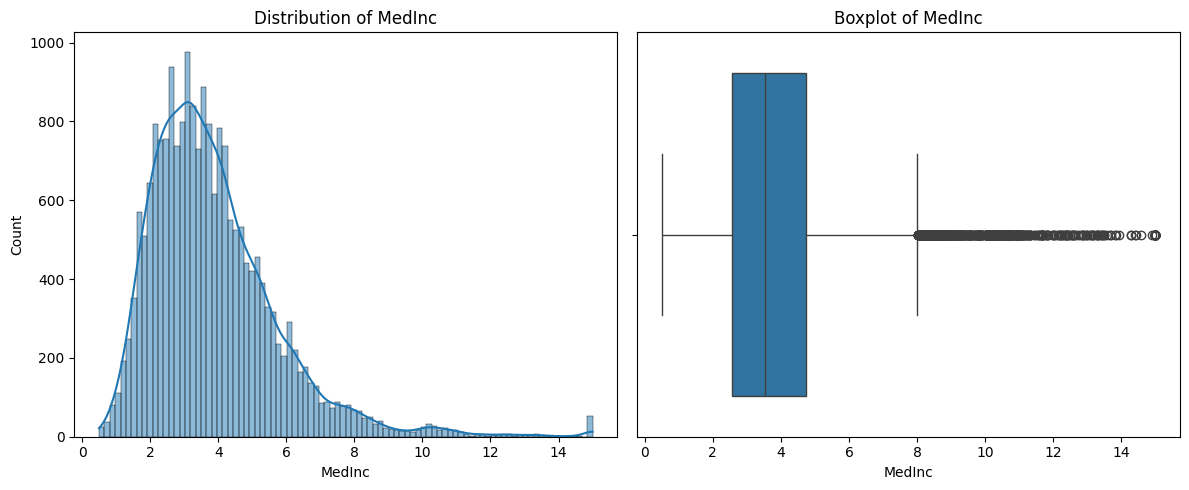

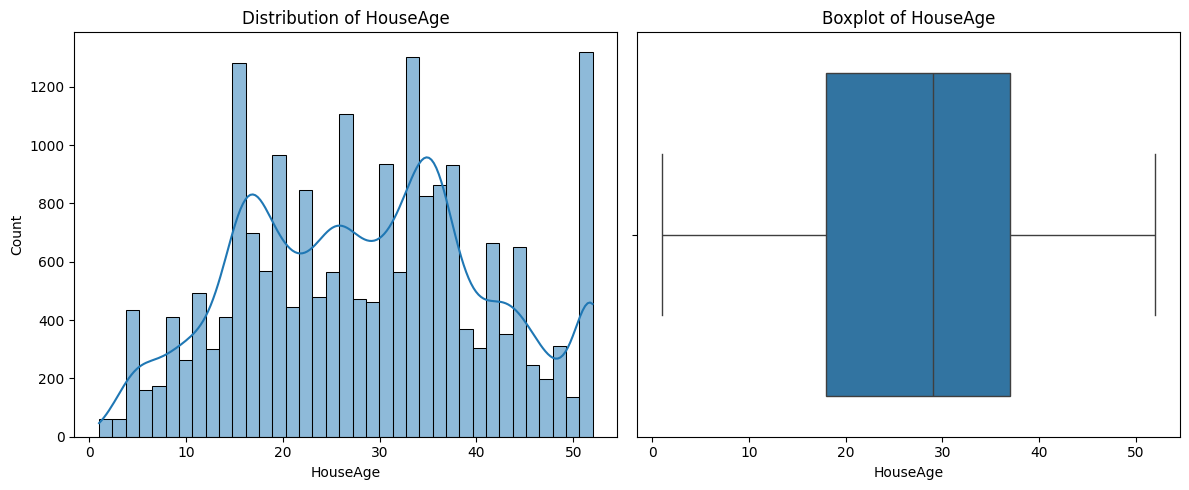

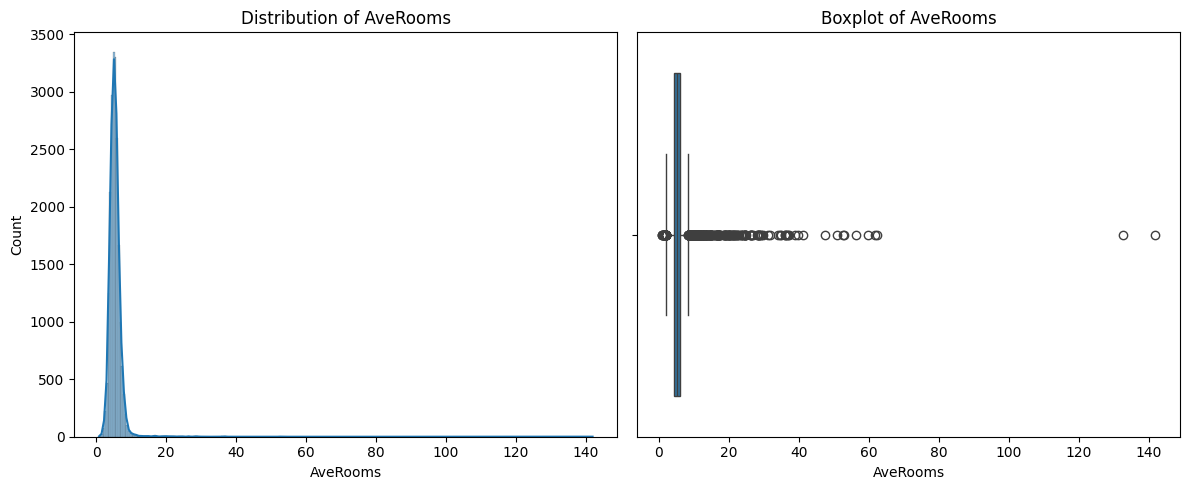

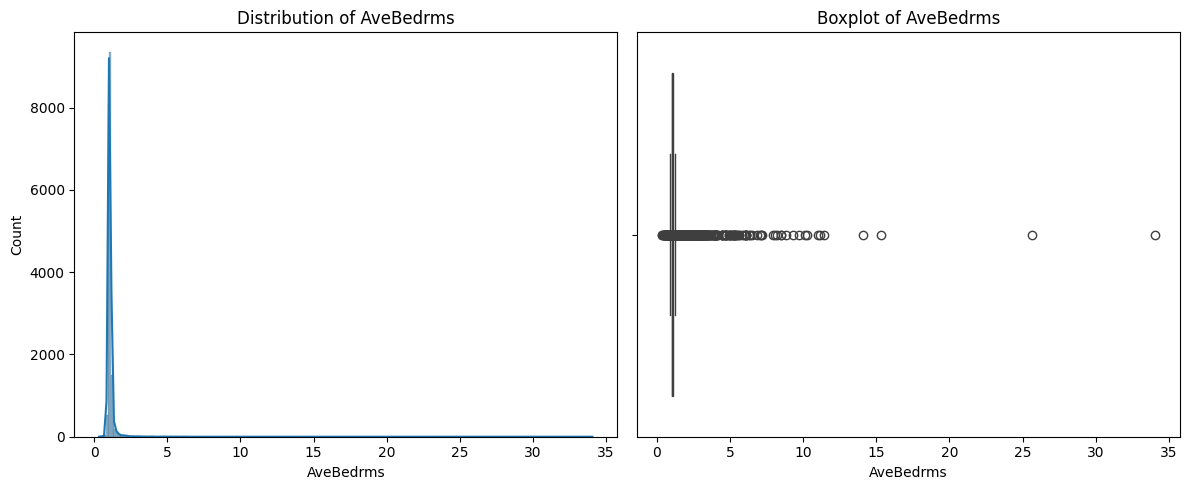

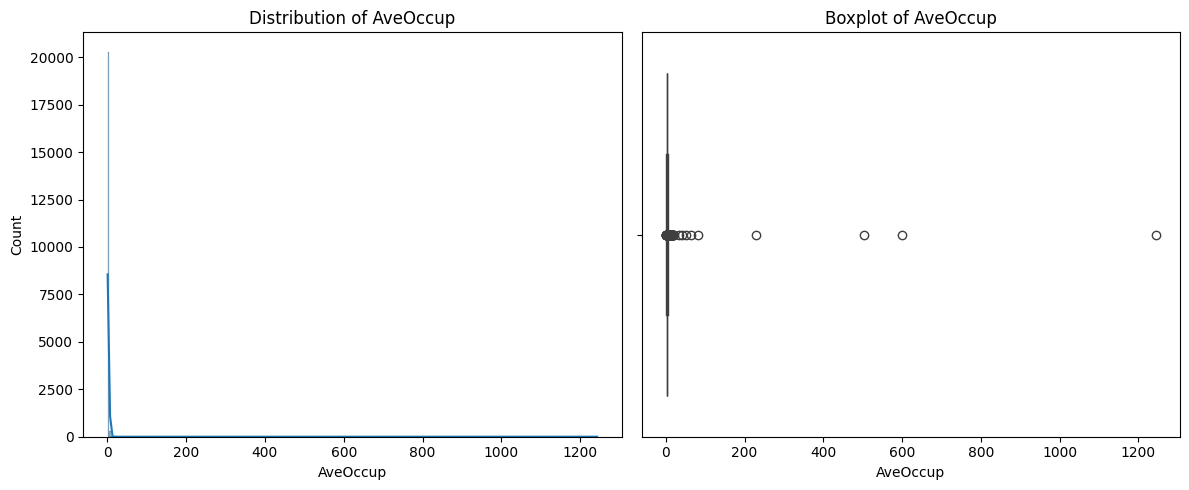

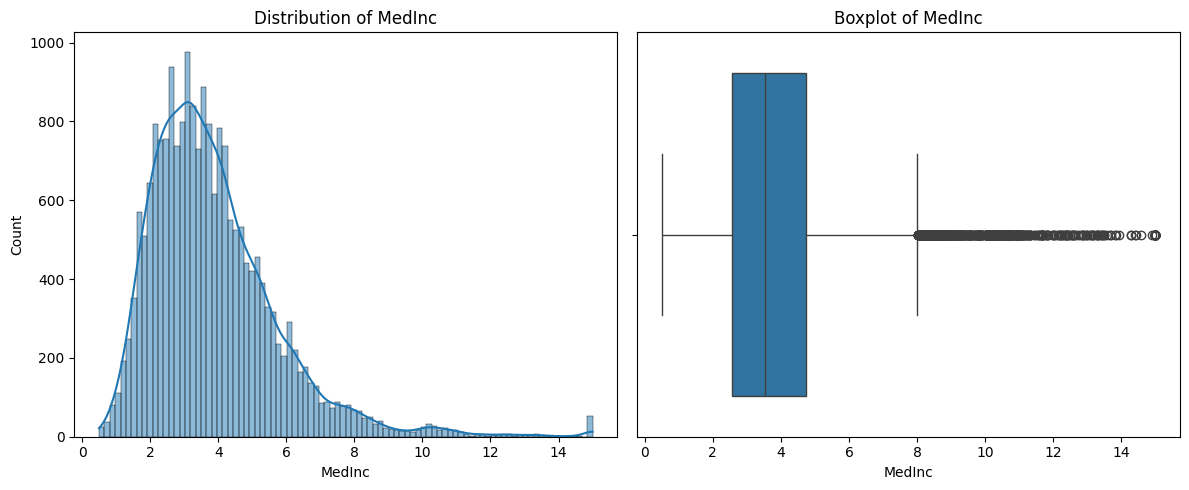

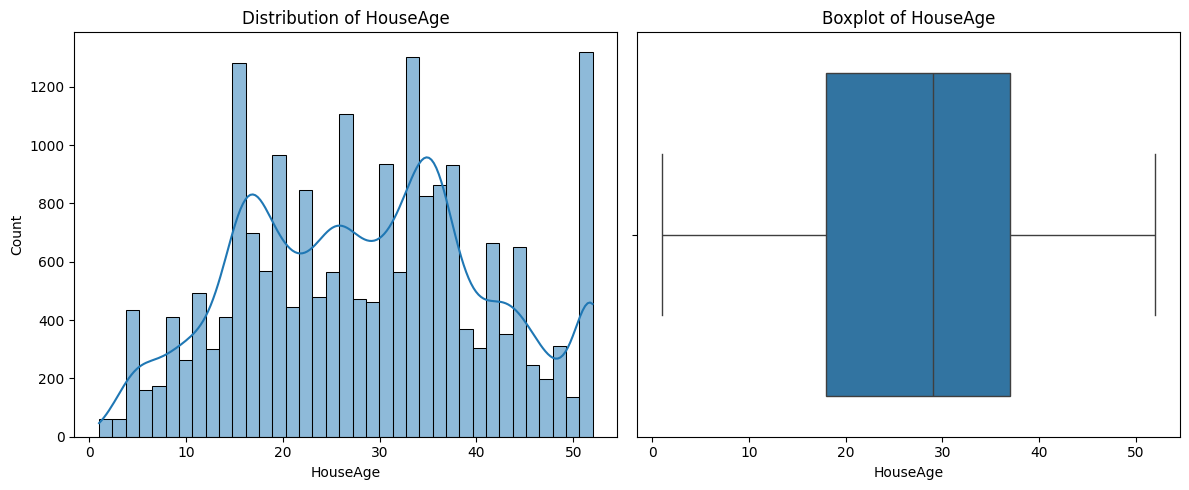

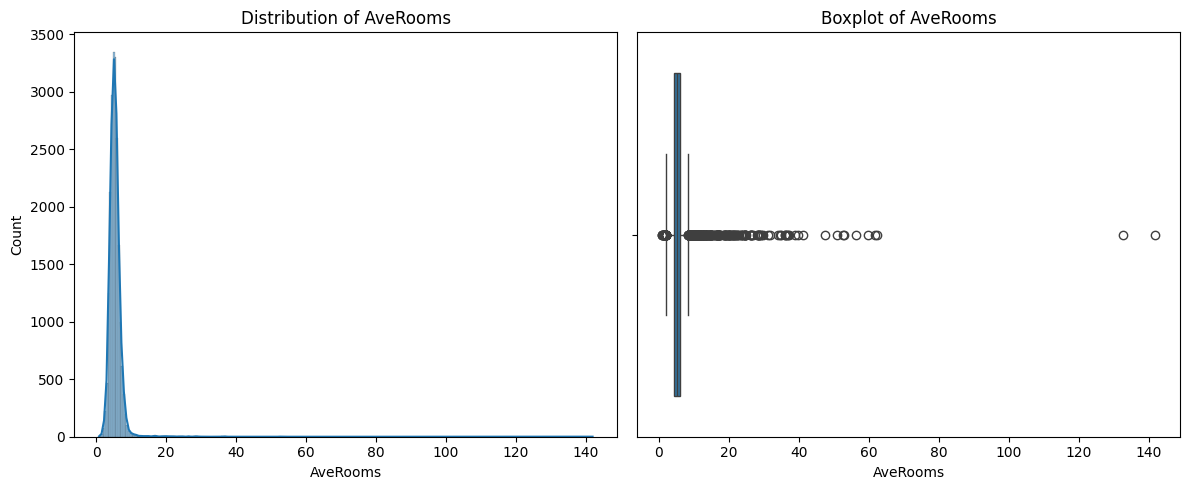

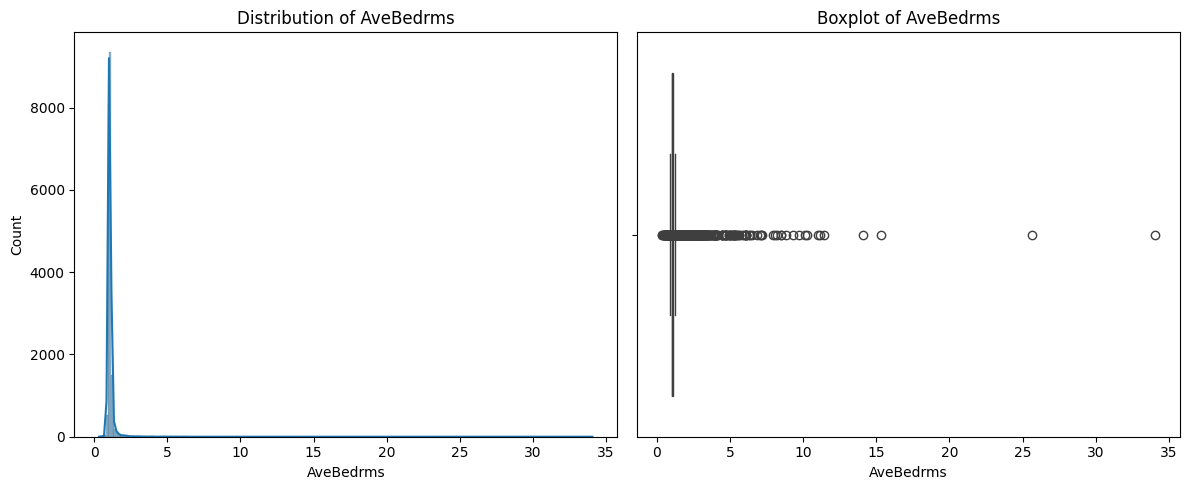

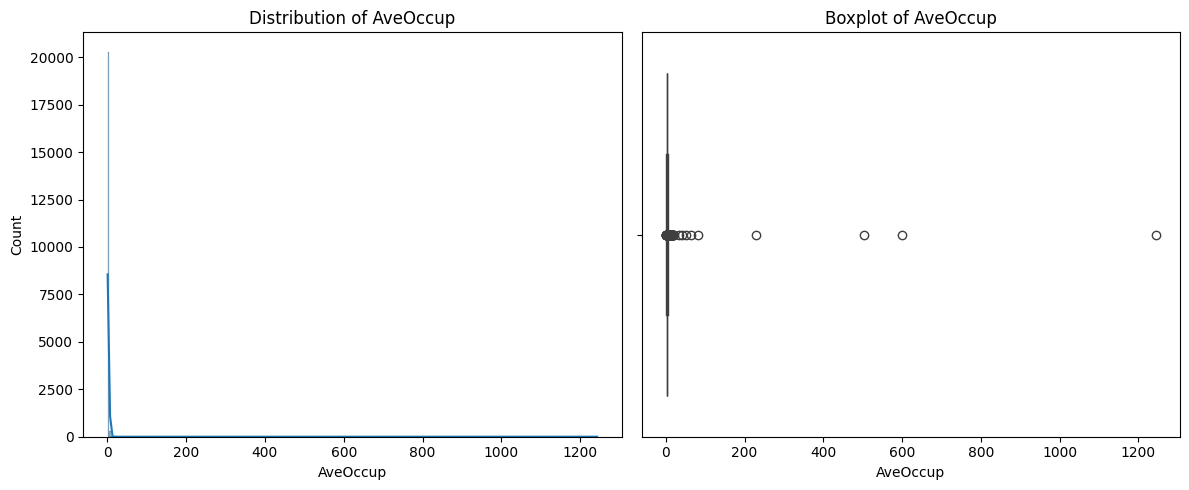

In [5]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
import matplotlib.pyplot as plt
import seaborn as sns
def plot_distributions_and_outliers(df, columns):
    for column in columns:
        plt.figure(figsize=(12, 5))
        
        # Plot distribusi data
        plt.subplot(1, 2, 1)
        sns.histplot(df[column], kde=True)
        plt.title(f'Distribution of {column}')
        
        # Plot boxplot untuk melihat outlier
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[column])
        plt.title(f'Boxplot of {column}')
        
        plt.tight_layout()
        plt.show()
# Daftar nama kolom yang ingin Anda cek
columns_to_check = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']
plot_distributions_and_outliers(df_california, columns_to_check)     

# Loop untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
for column in columns_to_check:
    checker = df_california[column]
    plt.figure(figsize=(12, 5))
    # Plot distribusi data
    plt.subplot(1, 2, 1)
    sns.histplot(checker, kde=True)
    plt.title(f'Distribution of {column}')
    # Plot boxplot untuk melihat outlier
    plt.subplot(1, 2, 2)
    sns.boxplot(x=checker)
    plt.title(f'Boxplot of {column}')
        
                
                    
    plt.tight_layout()
        
            
                    
                               


### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

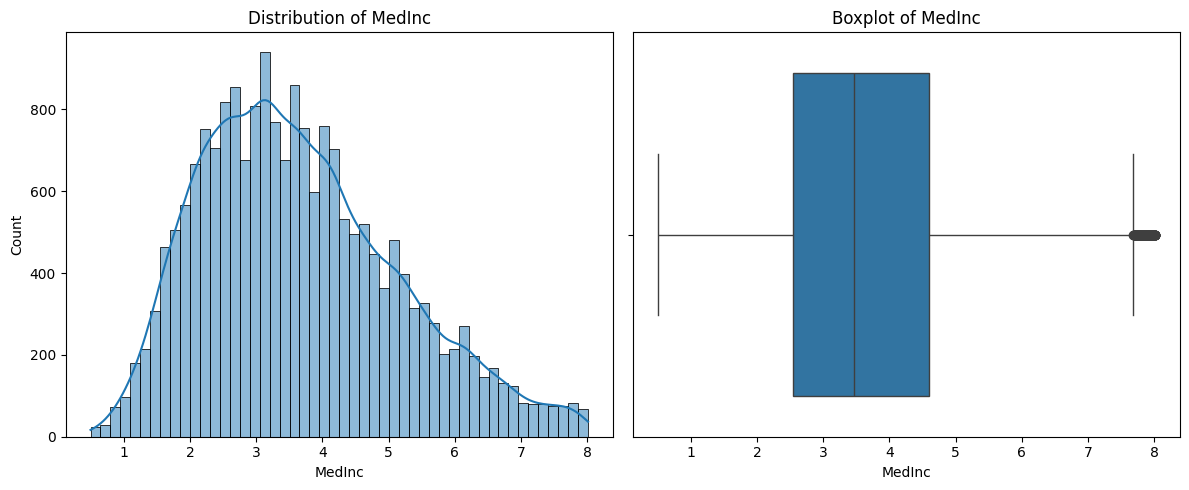

In [6]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
def handle_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_boundr = Q1 - 1.5 * IQR
    upper_boundr = Q3 + 1.5 * IQR
    df_cleaned = df[(df[column] >= lower_boundr) & (df[column] <= upper_boundr)]
    return df_cleaned

# Dan cek kembali distribusi data dan outliernya setelah di-handle
df_california_cleaned = handle_outliers_iqr(df_california, 'MedInc')
plot_distributions_and_outliers(df_california_cleaned, ['MedInc'])

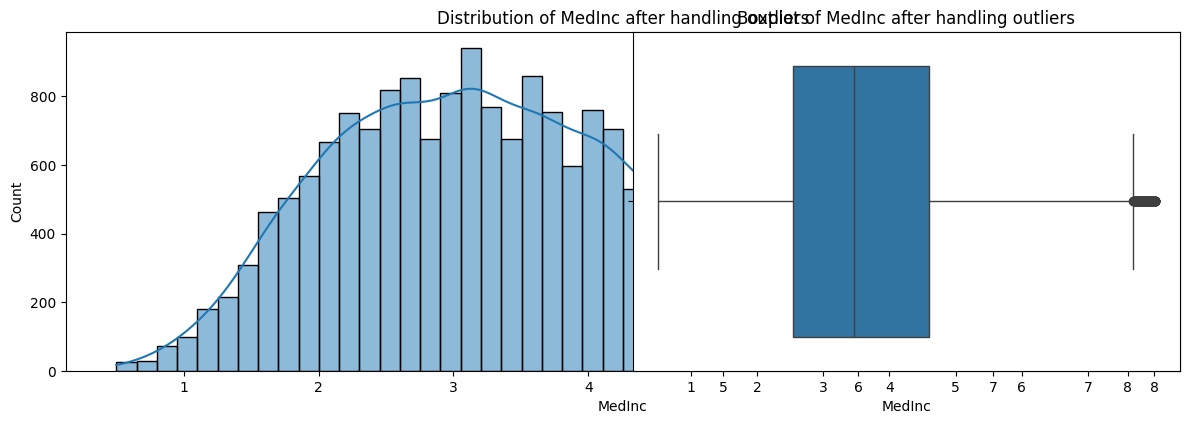

In [7]:
# Melakukan loop untuk mengecek distribusi tiap kolom
medinc = ['MedInc']
for column in medinc:
    df  = df_california_cleaned[column]
    plt.figure(figsize=(12, 5))
    # Plot distribusi data setelah handling outlier
    sns.histplot(df, kde=True)
    plt.title(f'Distribution of {column} after handling outliers')
    # Plot boxplot untuk melihat outlier setelah handling outlier
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df)
    plt.title(f'Boxplot of {column} after handling outliers')
    plt.tight_layout()
    plt.show()

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [8]:
df_company = pd.read_csv('company.csv')

                                                                            

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [9]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu
train,clfr = train_test_split(df_company, test_size=0.2, random_state=42)

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

In [10]:
df_company.head()

,Revenue,Size,Rating,Headquarters
0,Unknown / Non-Applicable,1001 to 5000 employees,3.1,"New York, NY"
1,$1 to $2 billion (USD),5001 to 10000 employees,4.2,"Herndon, VA"
2,$100 to $500 million (USD),1001 to 5000 employees,3.8,"Boston, MA"
3,$100 to $500 million (USD),501 to 1000 employees,3.5,"Bad Ragaz, Switzerland"
4,Unknown / Non-Applicable,51 to 200 employees,2.9,"New York, NY"


## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [10]:
#Tulis jawaban missing value handling kolom Headquarters disini
# Define the variable first
df_company = pd.read_csv('company.csv')




In [12]:
df_company.isna().sum()

Revenue         0
Size            0
Rating          0
Headquarters    0
dtype: int64

In [11]:
for column in df_company.columns:
    print(f"Jumlah missing value pada kolom {column}: {df_company[column].isna().sum()}")   
    display(df_company[column].value_counts())
    print("\n")

Jumlah missing value pada kolom Revenue: 0


Revenue
Unknown / Non-Applicable            213
$100 to $500 million (USD)           94
$10+ billion (USD)                   63
$2 to $5 billion (USD)               45
$10 to $25 million (USD)             41
$1 to $2 billion (USD)               36
$25 to $50 million (USD)             36
$50 to $100 million (USD)            31
$1 to $5 million (USD)               31
-1                                   27
$500 million to $1 billion (USD)     19
$5 to $10 million (USD)              14
Less than $1 million (USD)           14
$5 to $10 billion (USD)               8
Name: count, dtype: int64



Jumlah missing value pada kolom Size: 0


Size
51 to 200 employees        135
1001 to 5000 employees     104
1 to 50 employees           86
201 to 500 employees        85
10000+ employees            80
501 to 1000 employees       77
5001 to 10000 employees     61
-1                          27
Unknown                     17
Name: count, dtype: int64



Jumlah missing value pada kolom Rating: 0


Rating
 3.5    58
-1.0    50
 3.3    41
 4.0    41
 3.9    40
 3.8    39
 3.7    38
 5.0    36
 4.5    32
 3.6    31
 3.4    31
 4.2    29
 4.1    25
 4.4    24
 4.7    22
 3.2    21
 4.8    20
 2.9    14
 4.3    14
 3.1    12
 4.6    12
 4.9    11
 2.7    10
 3.0     7
 2.6     4
 2.8     3
 2.5     2
 2.2     1
 2.4     1
 2.3     1
 2.1     1
 2.0     1
Name: count, dtype: int64



Jumlah missing value pada kolom Headquarters: 0


Headquarters
New York, NY                 33
San Francisco, CA            31
-1                           31
Chicago, IL                  23
Boston, MA                   19
Reston, VA                   14
Mc Lean, VA                  13
Westminster, CO              12
Cambridge, MA                10
Cambridge, United Kingdom    10
Vienna, VA                    8
Herndon, VA                   7
Bedford, MA                   7
Saint Louis, MO               7
Washington, DC                7
Denver, CO                    7
Arlington, VA                 7
San Jose, CA                  7
Woodbine, MD                  7
Basel, Switzerland            6
Mountain View, CA             6
Chantilly, VA                 6
San Rafael, CA                6
San Antonio, TX               6
Princeton, NJ                 5
Bellevue, WA                  5
Rockville, MD                 5
Bethesda, MD                  5
Fairfax, VA                   5
Springfield, MA               5
Houston, TX                

In [12]:
# Checking the missing value in rating
100* len(df_company[df_company['Rating']==-1]) / len(df_company)


7.440476190476191

In [13]:
# Checking the missing value in rating
100* len(df_company[df_company['Size'].isin(['-1', 'Unknown'])]) / len(df_company)

6.5476190476190474

# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [14]:
import pandas as pd

df_churn = pd.read_csv('TelcoCustomerChurn.csv')
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
#Splitting terlebih dahulu
train,clfr = train_test_split(df_churn, test_size=0.2, random_state=42) 


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [65]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder
df_churn['StreamingMovies'] = df_churn['StreamingMovies'].replace({'No internet service': 'No'})

# Initialisasi LabelEncoder
label_encoder = LabelEncoder()


In [50]:
train.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2142,2370,0,0,0,1,21,1,0,0,2,0,2,0,0,2,1,0,3,586,492,0
1623,3457,0,0,0,0,54,1,2,1,0,2,0,0,2,2,2,1,0,1170,3511,0
6074,2149,1,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,2,59,1566,1
1362,1426,1,0,0,0,4,1,0,1,0,0,0,0,0,0,0,1,2,674,1627,1
6754,1545,1,0,0,1,0,1,2,0,2,2,0,2,0,0,2,1,0,546,0,0


In [56]:
test.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000


## Selesai :)